# 1. Implementing Randomise search CV for KNN Classifier to find optimal parameter - Hyperparamter tunning.

In [2]:
# import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
import pandas as pd

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


# define the KNN classifier
knn = KNeighborsClassifier()

# define the hyperparameters and their respective ranges
param_dist = {'n_neighbors': [5, 10, 15],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'leaf_size': [30, 40, 50]}

# perform the RandomizedSearchCV
random_search = RandomizedSearchCV(knn, param_distributions=param_dist, cv=5, n_iter=20, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# print the best hyperparameters and the accuracy score
print('Best Hyperparameters:', random_search.best_params_)
print('Accuracy Score:', random_search.score(X_test, y_test))


Best Hyperparameters: {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
Accuracy Score: 0.9143457698370994


## 2. Training with the optimal hyperparameter and finding the best accuracy

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.9623356002230776
Confusion Matrix :  [[4796  594]
 [ 384 5644]]
Precision Score :  0.9047771721705675
Recall Score :  0.9362972793629728
Accuracy Score :  0.9143457698370994
F1 Score :  0.9202674058372738
Time Taken to train and test :  327.4374279975891


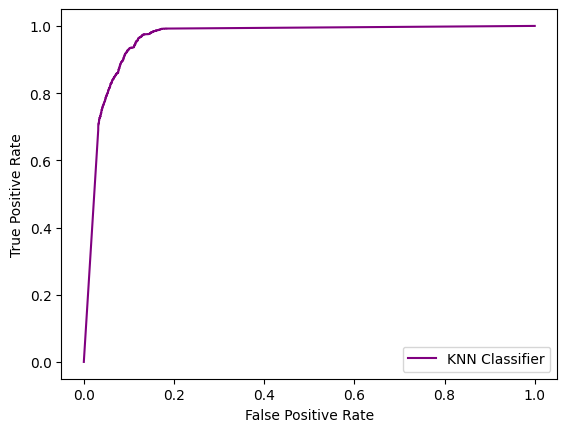

In [2]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time


print("Started...")

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

optimal_params_frm_RS = {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
# Define the model

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier(**optimal_params_frm_RS)
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/knn_classifier_model.sav"
# pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()


### 3. Test on the Dataset 

/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


KNN test roc-auc: 0.6373694612940407


/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix :  [[1378 2269]
 [ 496 3040]]
Precision Score :  0.5726125447353551
Recall Score :  0.8597285067873304
Accuracy Score :  0.6150633440066825
F1 Score :  0.6873940079140758
Time Taken to train and test :  9308.844592809677


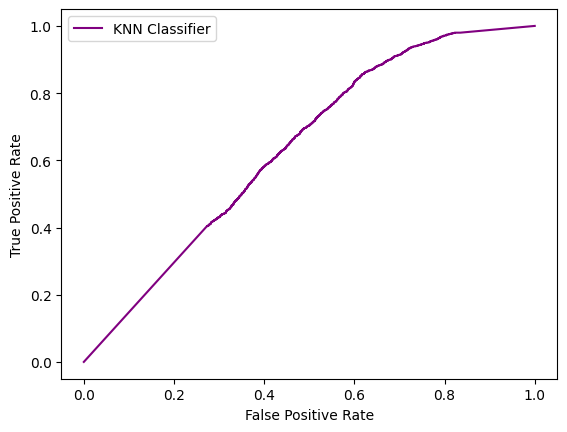

In [4]:
# We are using KNN classifier trained on earlier cell

import pandas as pd


# Load the dataset
data = pd.read_csv('2203_test_dataframe.csv', header=None)

X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/knn_classifier_model.sav"
# pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()




### 4. Perform Feature Engineering and training.May result better performance

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.9627884036524664
Confusion Matrix :  [[4788  602]
 [ 373 5655]]
Precision Score :  0.9037877577113633
Recall Score :  0.938122096881221
Accuracy Score :  0.9146085128744088
F1 Score :  0.9206349206349207
Time Taken to train and test :  306.03780698776245


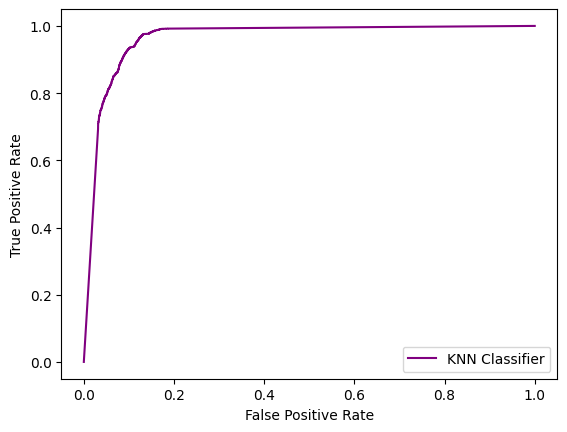

In [5]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time


print("Started...")

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)




optimal_params_frm_RS = {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
# Define the model

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier(**optimal_params_frm_RS)
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/knn_classifier_model.sav"
# pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()




## 5. Testing the accuracy after performing feature engineering

/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


KNN test roc-auc: 0.6277488036407535
Confusion Matrix :  [[1357 2290]
 [ 510 3026]]
Precision Score :  0.5692249811888638
Recall Score :  0.8557692307692307
Accuracy Score :  0.6101907281080329
F1 Score :  0.683687302304564
Time Taken to train and test :  480.88680386543274


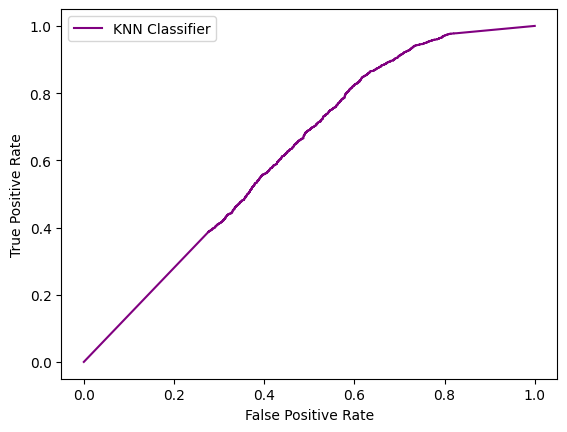

In [6]:
# We are using KNN classifier trained on earlier cell

import pandas as pd


# Load the dataset
data = pd.read_csv('2203_test_dataframe.csv', header=None)

X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


# using the previous standard_scalar to transform
X_test = min_max_scaler.transform(X_test)


ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/knn_classifier_model.sav"
# pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()

#### Accuracy doesnot seems to improve. Maybe because of stochastic nature of algorithm

# As a next step, the data is recollected. 10 labels up and down the outlier classifiers are removed manually from the folders by the help of json files.

### 1. Retraining the KNN Classifier with new dataset and finding the new optimum hyper parameter. We do feature scaling also to prevent overfitting.

In [1]:
# import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
data = pd.read_csv('20k_dataframe_2303.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)


# define the KNN classifier
knn = KNeighborsClassifier()

# define the hyperparameters and their respective ranges
param_dist = {'n_neighbors': [5, 10, 15],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'leaf_size': [30, 40, 50]}

# perform the RandomizedSearchCV
random_search = RandomizedSearchCV(knn, param_distributions=param_dist, cv=5, n_iter=20, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# print the best hyperparameters and the accuracy score
print('Best Hyperparameters:', random_search.best_params_)
print('Accuracy Score:', random_search.score(X_test, y_test))


Best Hyperparameters: {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
Accuracy Score: 0.9360222531293463


## 2. Training with the tuned hyperparameters

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.9790530454411185
Confusion Matrix :  [[2290  180]
 [ 126 2437]]
Precision Score :  0.9312189529996179
Recall Score :  0.9508388607101054
Accuracy Score :  0.9392012716073912
F1 Score :  0.9409266409266409
Time Taken to train and test :  12.332267999649048


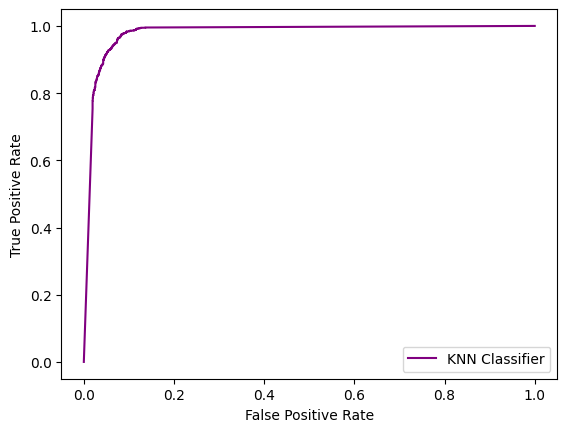

In [4]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

folder_name= "final_trained_knn"

# Load the dataset
data = pd.read_csv('20k_dataframe_2303.csv', header=None)

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)


# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)




optimal_params_frm_RS = {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
# Define the model

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier(**optimal_params_frm_RS)
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = f"{folder_name}/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()




## 3. Testing the model in data collected on 2203.

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.9964421538173285
Confusion Matrix :  [[ 9765   180]
 [  126 10060]]
Precision Score :  0.982421875
Recall Score :  0.9876300805026507
Accuracy Score :  0.9847995628632458
F1 Score :  0.985019093312445
Time Taken to train and test :  27.764654874801636


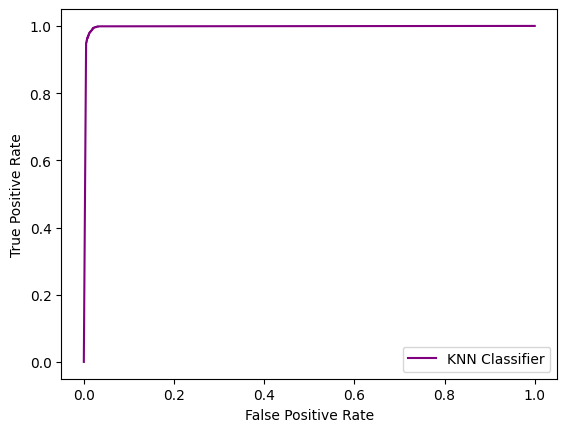

In [5]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

# Load the dataset
data = pd.read_csv('20k_dataframe_2303.csv', header=None)

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable




# For test data we transform based on fitting on training data. It is taken from RAM, not initialized here
X_test = min_max_scaler.transform(X_test)


start_time = time.time()
# Use the pretrained available on RAM -  KNN Classifier

ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()




## 4. Testing the model with new dataset from the pickle file.

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.6630142220035806
Confusion Matrix :  [[1546 2101]
 [ 388 3148]]
Precision Score :  0.5997332825300057
Recall Score :  0.8902714932126696
Accuracy Score :  0.653487400807462
F1 Score :  0.7166761525327263
Time Taken to train and test :  17.151453018188477


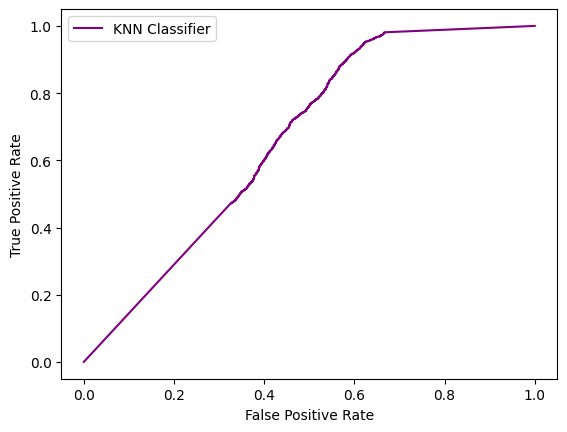

In [9]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

folder_name = "final_trained_knn"

# Load the dataset
data = pd.read_csv('2203_test_dataframe.csv', header=None)

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

knn_classifier = pickle.load(open(f"{folder_name}/knn_classifier_model.sav", "rb"))


# For test data we transform based on fitting on training data. It is taken from RAM, not initialized here
X_test = min_max_scaler.transform(X_test)


start_time = time.time()
# Use the pretrained available on RAM -  KNN Classifier

ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()




In [10]:
# Saving the fitted normalized data to later use for transformation of raw data.

import pickle
pickle.dump(min_max_scaler, open("final_trained_knn/min_max_scalar.pkl", "wb"))

## 5. Testing the saved model with the dataset collected on 2403

Started...
KNN test roc-auc: 0.6307474400000002
Confusion Matrix :  [[1266 1234]
 [ 724 1776]]
Precision Score :  0.5900332225913621
Recall Score :  0.7104
Accuracy Score :  0.6084
F1 Score :  0.6446460980036298
Time Taken to train and test :  6.023698329925537


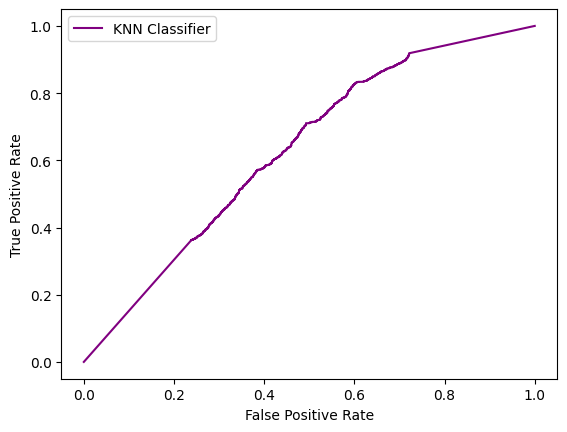

In [5]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

folder_name = "final_trained_knn"

# Load the dataset
data = pd.read_csv('test_dataframe_2403.csv', header=None)

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

knn_classifier = pickle.load(open(f"{folder_name}/knn_classifier_model.sav", "rb"))

min_max_scaler = pickle.load(open(f"{folder_name}/min_max_scalar.pkl", "rb"))


# For test data we transform based on fitting on training data. It is taken from RAM, not initialized here
X_test = min_max_scaler.transform(X_test)


start_time = time.time()
# Use the pretrained available on RAM -  KNN Classifier


ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/test2403_roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()





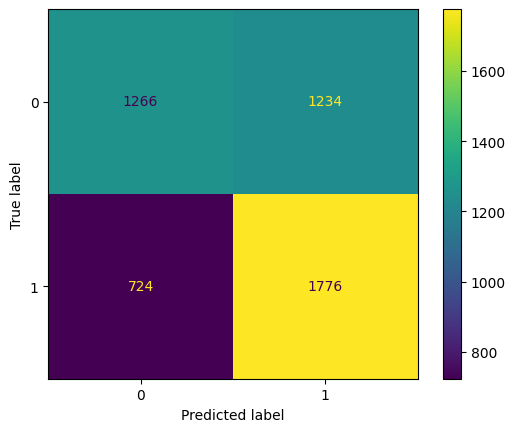

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

cm = knn_conf_matx
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_)
disp.plot()

plt.show()